<a href="https://colab.research.google.com/github/rfortuna98/QNC-Fall-2025/blob/main/Ex_Phe_coc_fem_SAvsRE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd

file_path = "/content/drive/MyDrive/Colab Notebooks/Ex-Phe Compiled Data ALxBW.csv"

# Load the file without header guessing
raw = pd.read_csv(file_path, header=None)

# Show the first 5 rows to see header structure
print(raw.head(5))

       0       1          2              3            4       5       6   \
0     NaN     NaN        NaN             SA           SA     NaN     NaN   
1  Cohort  Animal  Treatment  Active levers  Weight 0hrs  Cohort  Animal   
2     CH1       2     0ug/kg            187          338     CH1       2   
3     CH1       2     3ug/kg            175          330     CH1       2   
4     CH1       2    10ug/kg             26          335     CH1       2   

          7              8            9   ...  18  19  20  21  22  23  24  25  \
0        NaN             RE           RE  ... NaN NaN NaN NaN NaN NaN NaN NaN   
1  Treatment  Active levers  Weight 0hrs  ... NaN NaN NaN NaN NaN NaN NaN NaN   
2     0ug/kg            NaN         341*  ... NaN NaN NaN NaN NaN NaN NaN NaN   
3     3ug/kg            58*         341*  ... NaN NaN NaN NaN NaN NaN NaN NaN   
4    10ug/kg            25*         349*  ... NaN NaN NaN NaN NaN NaN NaN NaN   

   26  27  
0 NaN NaN  
1 NaN NaN  
2 NaN NaN  
3 NaN Na


=== Average Active Levers by Treatment and Cohort ===
  Cohort Treatment  SA Active levers  RE Active levers
0    CH1    0ug/kg            139.20            181.80
1    CH1   10ug/kg             99.40            135.20
2    CH1    3ug/kg            108.20            157.20
3    CH2    0ug/kg            103.75            280.50
4    CH2   10ug/kg             51.25            126.25
5    CH2    3ug/kg             80.75            190.00

✅ Saved summary to 'SA_RE_active_lever_summary.csv'


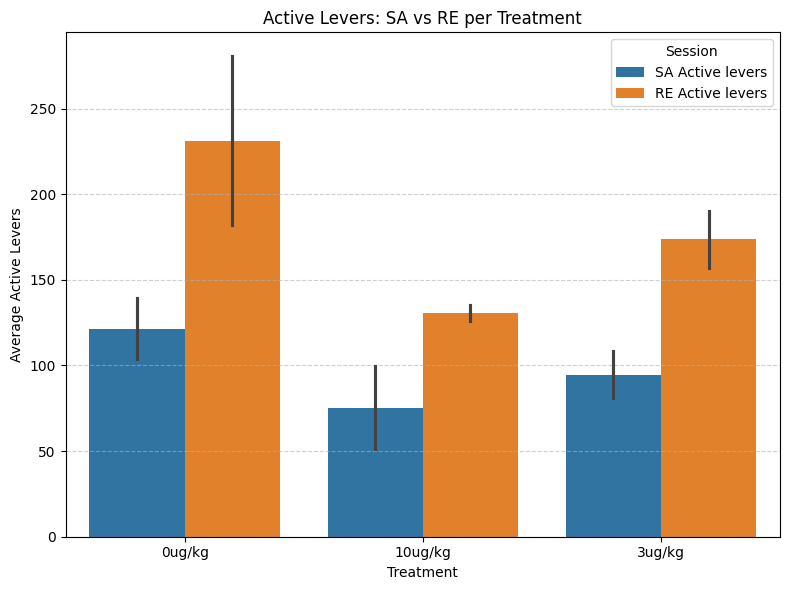

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === Load Data ===
file_path = "/content/drive/MyDrive/Colab Notebooks/Ex-Phe Compiled Data ALxBW.csv"
raw = pd.read_csv(file_path, header=[0, 1])

# --- Re-read cleanly without multi-level confusion ---
raw = pd.read_csv(file_path, header=None, skiprows=2)
raw = raw.iloc[:, :10]  # first 10 cols contain data we need

# --- Assign clear column names ---
raw.columns = [
    "Cohort_SA", "Animal_SA", "Treatment_SA", "SA Active levers", "SA Weight",
    "Cohort_RE", "Animal_RE", "Treatment_RE", "RE Active levers", "RE Weight"
]

# --- Drop rows missing core values ---
raw = raw.dropna(subset=["Treatment_SA", "Treatment_RE"])

# --- Clean numeric data ---
def clean_numeric(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in ["N/A", "NaN", ""]:
        return np.nan
    if "*" in x:  # exclude starred values
        return np.nan
    try:
        return float(x)
    except ValueError:
        return np.nan

raw["SA Active levers"] = raw["SA Active levers"].apply(clean_numeric)
raw["RE Active levers"] = raw["RE Active levers"].apply(clean_numeric)

# --- Keep only clean rows ---
df = raw.dropna(subset=["SA Active levers", "RE Active levers"]).copy()

# === Summary statistics ===
summary = (
    df.groupby(["Cohort_SA", "Treatment_SA"])[["SA Active levers", "RE Active levers"]]
    .mean()
    .reset_index()
    .rename(columns={
        "Cohort_SA": "Cohort",
        "Treatment_SA": "Treatment"
    })
)

print("\n=== Average Active Levers by Treatment and Cohort ===")
print(summary)

# === Save summary ===
summary.to_csv("SA_RE_active_lever_summary.csv", index=False)
print("\n✅ Saved summary to 'SA_RE_active_lever_summary.csv'")

# === Visualization ===
plt.figure(figsize=(8,6))
sns.barplot(
    data=summary.melt(id_vars=["Cohort", "Treatment"],
                      value_vars=["SA Active levers", "RE Active levers"],
                      var_name="Session", value_name="Active Levers"),
    x="Treatment", y="Active Levers", hue="Session"
)
plt.title("Active Levers: SA vs RE per Treatment")
plt.xlabel("Treatment")
plt.ylabel("Average Active Levers")
plt.legend(title="Session")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Pearson correlation (linear): 0.471
Spearman correlation (rank-based): 0.368


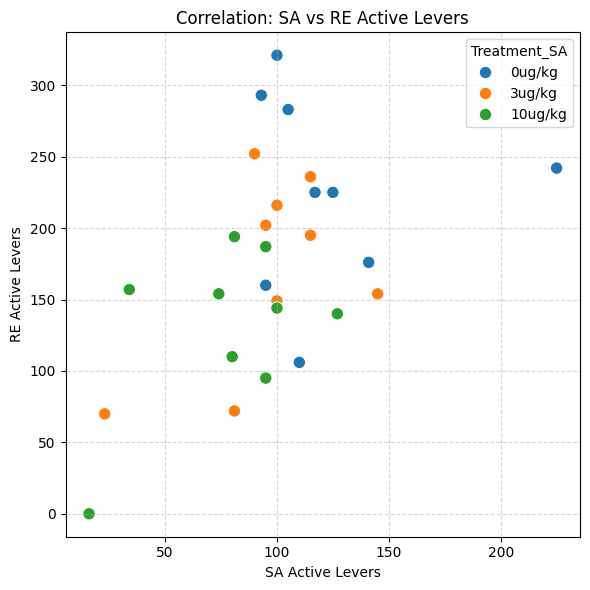

In [17]:
# --- Correlation between SA and RE Active levers ---
corr_pearson = df["SA Active levers"].corr(df["RE Active levers"], method='pearson')
corr_spearman = df["SA Active levers"].corr(df["RE Active levers"], method='spearman')

print(f"Pearson correlation (linear): {corr_pearson:.3f}")
print(f"Spearman correlation (rank-based): {corr_spearman:.3f}")

# --- Optional: visualize correlation ---
plt.figure(figsize=(6,6))
sns.scatterplot(x="SA Active levers", y="RE Active levers", hue="Treatment_SA", data=df, s=80)
plt.title("Correlation: SA vs RE Active Levers")
plt.xlabel("SA Active Levers")
plt.ylabel("RE Active Levers")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [18]:
from scipy.stats import pearsonr, spearmanr

# --- Pearson correlation with p-value ---
pearson_corr, pearson_p = pearsonr(df["SA Active levers"], df["RE Active levers"])
print(f"Pearson correlation: {pearson_corr:.3f}, p-value: {pearson_p:.3e}")

# --- Spearman correlation with p-value ---
spearman_corr, spearman_p = spearmanr(df["SA Active levers"], df["RE Active levers"])
print(f"Spearman correlation: {spearman_corr:.3f}, p-value: {spearman_p:.3e}")


Pearson correlation: 0.471, p-value: 1.312e-02
Spearman correlation: 0.368, p-value: 5.875e-02


In [20]:
from scipy.stats import pearsonr

# --- Get unique treatments ---
treatments = df["Treatment_SA"].unique()

# --- Compute correlation per treatment ---
treatment_corrs = []

for tr in treatments:
    subset = df[df["Treatment_SA"] == tr]
    if len(subset) > 1:  # need at least 2 points
        corr, pval = pearsonr(subset["SA Active levers"], subset["RE Active levers"])
        treatment_corrs.append((tr, corr, pval))
    else:
        treatment_corrs.append((tr, np.nan, np.nan))  # not enough data

# --- Display results ---
print("Correlation between SA and RE Active Levers per Treatment:\n")
for tr, corr, pval in treatment_corrs:
    print(f"{tr}: Pearson r = {corr:.3f}, p-value = {pval:.3}")


Correlation between SA and RE Active Levers per Treatment:

0ug/kg: Pearson r = -0.047, p-value = 0.904
3ug/kg: Pearson r = 0.530, p-value = 0.142
10ug/kg: Pearson r = 0.508, p-value = 0.163


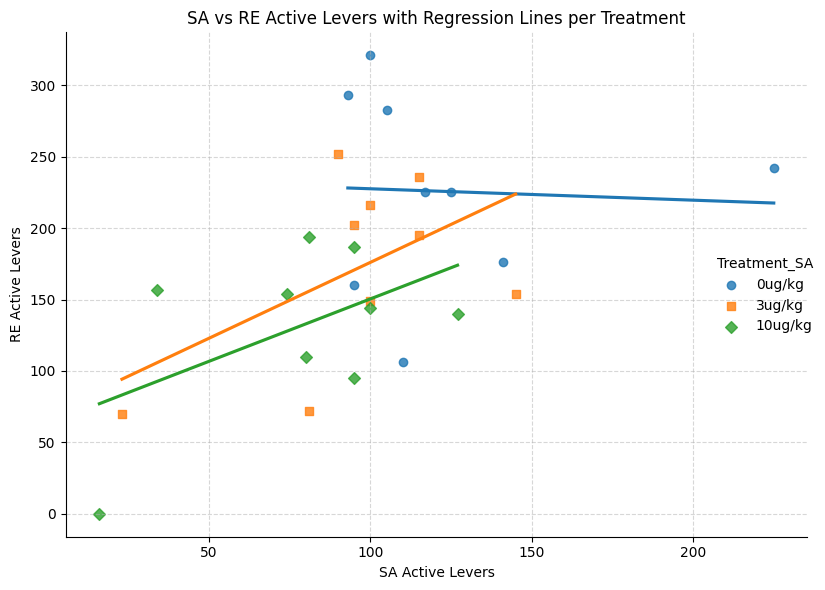

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Scatter plot with regression line per treatment ---
sns.lmplot(
    data=df,
    x="SA Active levers",
    y="RE Active levers",
    hue="Treatment_SA",
    height=6,
    aspect=1.2,
    markers=["o", "s", "D"],  # Updated markers to match 3 treatments
    ci=None  # remove confidence interval for clarity
)

plt.title("SA vs RE Active Levers with Regression Lines per Treatment")
plt.xlabel("SA Active Levers")
plt.ylabel("RE Active Levers")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [23]:
from scipy.stats import pearsonr

cohorts = df["Cohort_SA"].unique()

for ch in cohorts:
    subset = df[df["Cohort_SA"] == ch]
    if len(subset) > 1:
        corr, pval = pearsonr(subset["SA Active levers"], subset["RE Active levers"])
        print(f"{ch}: Pearson r = {corr:.3f}, p-value = {pval:.3e}")
    else:
        print(f"{ch}: Not enough data for correlation")


CH1: Pearson r = 0.600, p-value = 1.804e-02
CH2: Pearson r = 0.856, p-value = 3.766e-04


In [24]:
summary_by_cohort = (
    df.groupby("Cohort_SA")[["SA Active levers", "RE Active levers"]]
    .mean()
    .reset_index()
)
print(summary_by_cohort)


  Cohort_SA  SA Active levers  RE Active levers
0       CH1        115.600000        158.066667
1       CH2         78.583333        198.916667


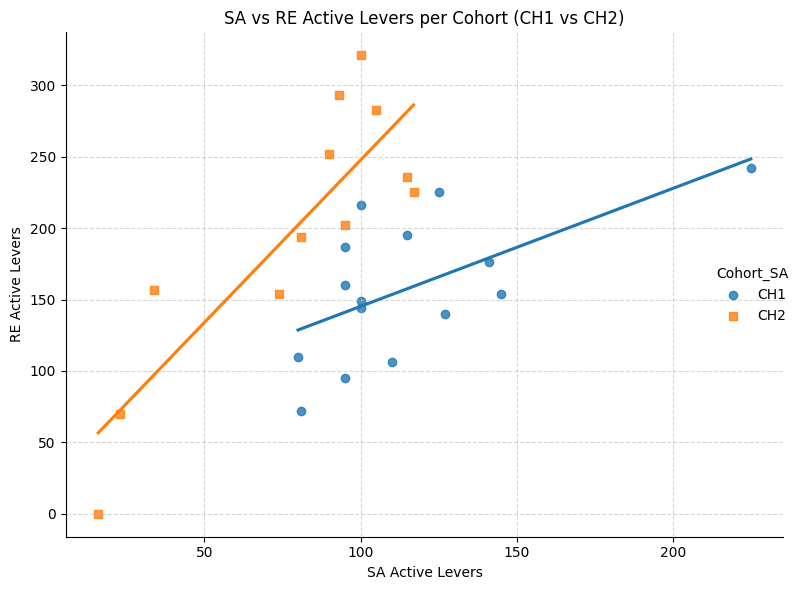

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(
    data=df,
    x="SA Active levers",
    y="RE Active levers",
    hue="Cohort_SA",
    height=6,
    aspect=1.2,
    markers=["o", "s"],  # different markers for CH1 vs CH2
    ci=None
)
plt.title("SA vs RE Active Levers per Cohort (CH1 vs CH2)")
plt.xlabel("SA Active Levers")
plt.ylabel("RE Active Levers")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [29]:
from scipy.stats import pearsonr

# Get unique cohorts and treatments
cohorts = df["Cohort_SA"].unique()
treatments = df["Treatment_SA"].unique()

# Loop through cohorts and treatments
results = []

for ch in cohorts:
    for tr in treatments:
        subset = df[(df["Cohort_SA"] == ch) & (df["Treatment_SA"] == tr)]
        if len(subset) > 1:  # need at least 2 points
            corr, pval = pearsonr(subset["SA Active levers"], subset["RE Active levers"])
            results.append((ch, tr, corr, pval))
        else:
            results.append((ch, tr, np.nan, np.nan))  # not enough data

# Display results
print("Correlation of SA vs RE Active Levers per Cohort × Treatment:\n")
for ch, tr, corr, pval in results:
    print(f"{ch} - {tr}: Pearson r = {corr:.3f}, p-value = {pval:.3}")


Correlation of SA vs RE Active Levers per Cohort × Treatment:

CH1 - 0ug/kg: Pearson r = 0.699, p-value = 0.189
CH1 - 3ug/kg: Pearson r = 0.387, p-value = 0.52
CH1 - 10ug/kg: Pearson r = 0.236, p-value = 0.702
CH2 - 0ug/kg: Pearson r = -0.832, p-value = 0.168
CH2 - 3ug/kg: Pearson r = 0.933, p-value = 0.0673
CH2 - 10ug/kg: Pearson r = 0.812, p-value = 0.188


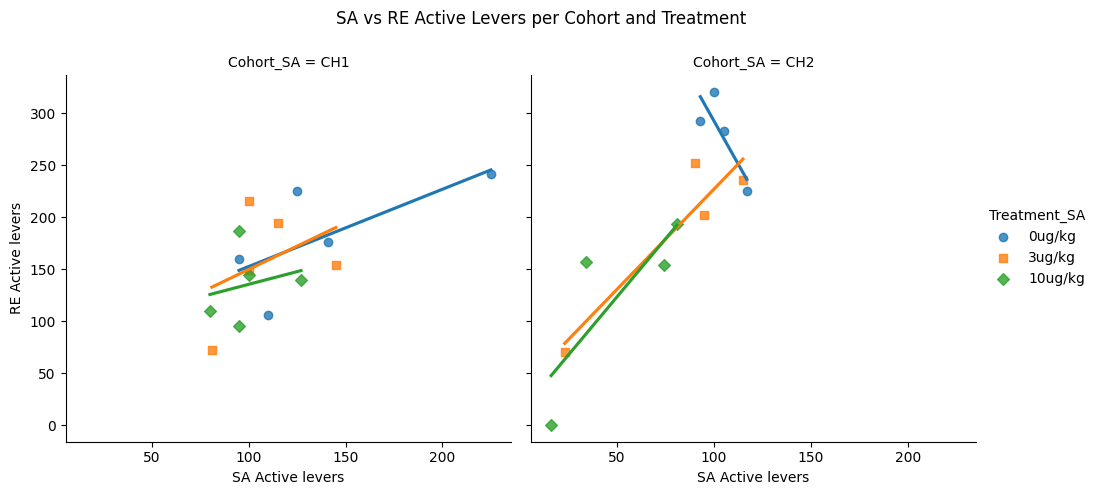

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(
    data=df,
    x="SA Active levers",
    y="RE Active levers",
    hue="Treatment_SA",
    col="Cohort_SA",        # split plots by cohort
    height=5,
    aspect=1,
    markers=["o", "s", "D"],  # Updated to 3 markers to match 3 treatments
    ci=None
)
plt.subplots_adjust(top=0.85)
plt.suptitle("SA vs RE Active Levers per Cohort and Treatment")
plt.show()

In [30]:
# Make sure weights are numeric
df["SA Weight"] = df["SA Weight"].apply(clean_numeric)
df["RE Weight"] = df["RE Weight"].apply(clean_numeric)

# Drop rows missing weights
df_weight = df.dropna(subset=["SA Weight", "RE Weight"])


In [31]:
from scipy.stats import pearsonr

correlations = []

# SA levers vs SA Weight
corr, pval = pearsonr(df_weight["SA Active levers"], df_weight["SA Weight"])
correlations.append(("SA Active levers vs SA Weight", corr, pval))

# RE levers vs RE Weight
corr, pval = pearsonr(df_weight["RE Active levers"], df_weight["RE Weight"])
correlations.append(("RE Active levers vs RE Weight", corr, pval))

# SA levers vs RE Weight
corr, pval = pearsonr(df_weight["SA Active levers"], df_weight["RE Weight"])
correlations.append(("SA Active levers vs RE Weight", corr, pval))

# RE levers vs SA Weight
corr, pval = pearsonr(df_weight["RE Active levers"], df_weight["SA Weight"])
correlations.append(("RE Active levers vs SA Weight", corr, pval))

# Display results
for desc, r, p in correlations:
    print(f"{desc}: r = {r:.3f}, p-value = {p:.3e}")


SA Active levers vs SA Weight: r = -0.244, p-value = 2.203e-01
RE Active levers vs RE Weight: r = -0.520, p-value = 5.410e-03
SA Active levers vs RE Weight: r = -0.274, p-value = 1.661e-01
RE Active levers vs SA Weight: r = -0.554, p-value = 2.703e-03


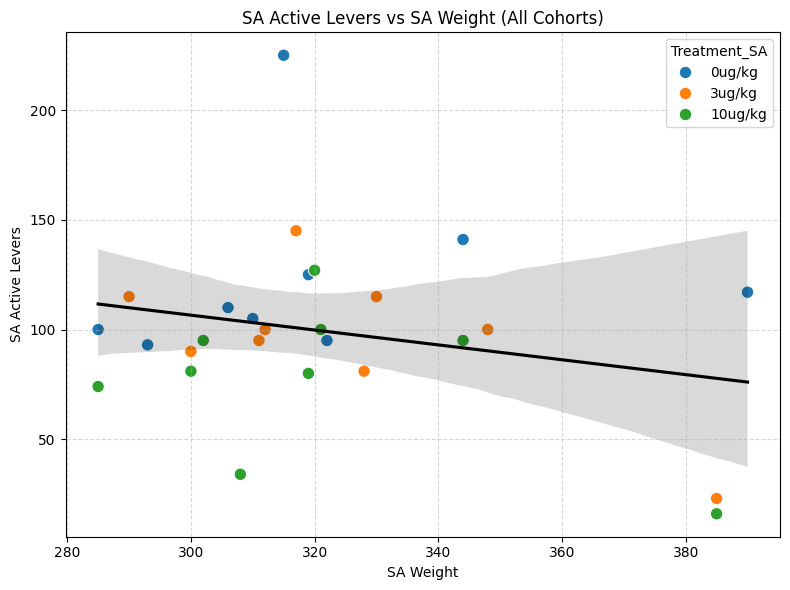

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt data to long format for easier plotting
df_long = df_weight.melt(
    id_vars=["Treatment_SA"],
    value_vars=["SA Active levers", "RE Active levers", "SA Weight", "RE Weight"],
    var_name="Measure",
    value_name="Value"
)

# Scatter plot: Active Levers vs Weights per Treatment
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_weight,
    x="SA Weight",
    y="SA Active levers",
    hue="Treatment_SA",
    s=80
)
sns.regplot(
    data=df_weight,
    x="SA Weight",
    y="SA Active levers",
    scatter=False,
    color="black"
)
plt.xlabel("SA Weight")
plt.ylabel("SA Active Levers")
plt.title("SA Active Levers vs SA Weight (All Cohorts)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [37]:
from scipy.stats import pearsonr

treatments = df_weight["Treatment_SA"].unique()
correlations = []

for tr in treatments:
    subset = df_weight[df_weight["Treatment_SA"] == tr]
    if len(subset) > 1:
        # SA Active levers vs SA Weight
        corr_sa, p_sa = pearsonr(subset["SA Active levers"], subset["SA Weight"])
        # RE Active levers vs RE Weight
        corr_re, p_re = pearsonr(subset["RE Active levers"], subset["RE Weight"])
        correlations.append((tr, corr_sa, p_sa, corr_re, p_re))
    else:
        correlations.append((tr, np.nan, np.nan, np.nan, np.nan))

# Display results
print("Correlation per Treatment (All Cohorts Combined):\n")
for tr, corr_sa, p_sa, corr_re, p_re in correlations:
    print(f"{tr}: SA levers vs SA Weight r={corr_sa:.3f}, p={p_sa:.6}; "
          f"RE levers vs RE Weight r={corr_re:.3f}, p={p_re:.6}")


Correlation per Treatment (All Cohorts Combined):

0ug/kg: SA levers vs SA Weight r=0.139, p=0.721632; RE levers vs RE Weight r=-0.231, p=0.54924
3ug/kg: SA levers vs SA Weight r=-0.691, p=0.0394426; RE levers vs RE Weight r=-0.820, p=0.00685373
10ug/kg: SA levers vs SA Weight r=-0.413, p=0.269567; RE levers vs RE Weight r=-0.976, p=6.61025e-06


In [42]:
from scipy.stats import pearsonr

# Ensure weights are numeric
df["SA Weight"] = df["SA Weight"].apply(clean_numeric)
df["RE Weight"] = df["RE Weight"].apply(clean_numeric)

# Drop rows with missing lever presses or weights
df_weight = df.dropna(subset=["SA Active levers", "RE Active levers", "SA Weight", "RE Weight"])

treatments = df_weight["Treatment_SA"].unique()
results = []

for tr in treatments:
    subset = df_weight[df_weight["Treatment_SA"] == tr]
    if len(subset) > 1:
        # SA Active Levers vs SA Weight
        corr_sa, p_sa = pearsonr(subset["SA Active levers"], subset["SA Weight"])
        # RE Active Levers vs RE Weight
        corr_re, p_re = pearsonr(subset["RE Active levers"], subset["RE Weight"])
        results.append((tr, corr_sa, p_sa, corr_re, p_re))
    else:
        results.append((tr, np.nan, np.nan, np.nan, np.nan))  # not enough data

# Display results
print("Correlation of Active Levers vs Weight per Treatment (All Cohorts Combined):\n")
for tr, corr_sa, p_sa, corr_re, p_re in results:
    print(f"{tr}: SA levers vs SA Weight r={corr_sa:.3f}, p={p_sa:.3e}; "
          f"RE levers vs RE Weight r={corr_re:.3f}, p={p_re:.3e}")


Correlation of Active Levers vs Weight per Treatment (All Cohorts Combined):

0ug/kg: SA levers vs SA Weight r=0.139, p=7.216e-01; RE levers vs RE Weight r=-0.231, p=5.492e-01
3ug/kg: SA levers vs SA Weight r=-0.691, p=3.944e-02; RE levers vs RE Weight r=-0.820, p=6.854e-03
10ug/kg: SA levers vs SA Weight r=-0.413, p=2.696e-01; RE levers vs RE Weight r=-0.976, p=6.610e-06


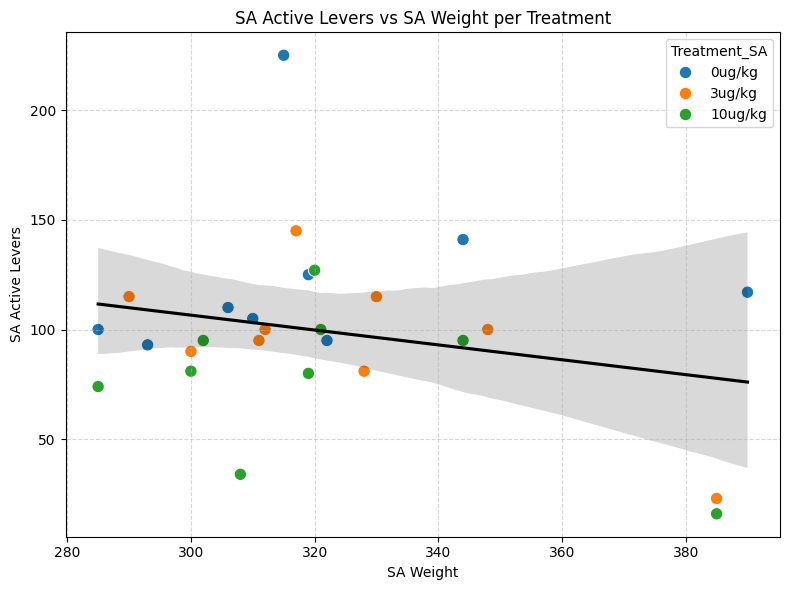

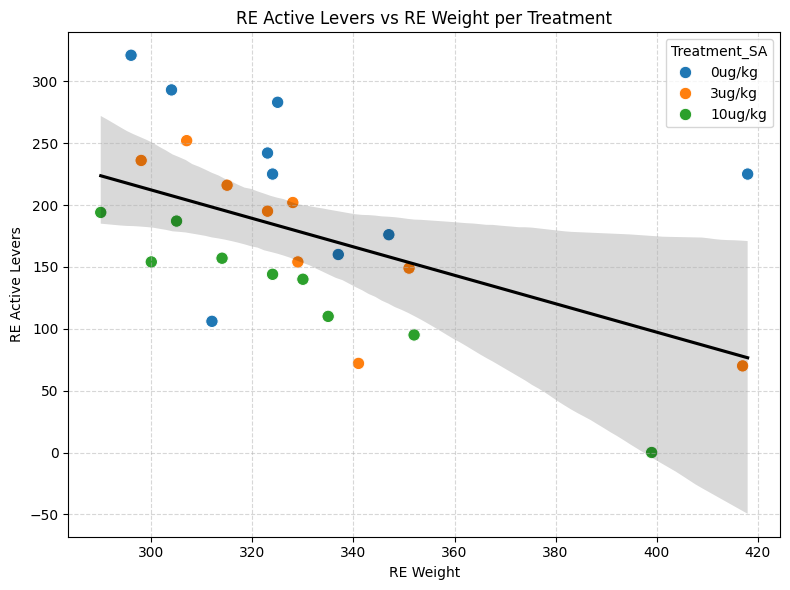

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# SA Active Levers vs SA Weight
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_weight,
    x="SA Weight",
    y="SA Active levers",
    hue="Treatment_SA",
    s=80
)
sns.regplot(
    data=df_weight,
    x="SA Weight",
    y="SA Active levers",
    scatter=False,
    color="black"
)
plt.title("SA Active Levers vs SA Weight per Treatment")
plt.xlabel("SA Weight")
plt.ylabel("SA Active Levers")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# RE Active Levers vs RE Weight
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_weight,
    x="RE Weight",
    y="RE Active levers",
    hue="Treatment_SA",
    s=80
)
sns.regplot(
    data=df_weight,
    x="RE Weight",
    y="RE Active levers",
    scatter=False,
    color="black"
)
plt.title("RE Active Levers vs RE Weight per Treatment")
plt.xlabel("RE Weight")
plt.ylabel("RE Active Levers")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


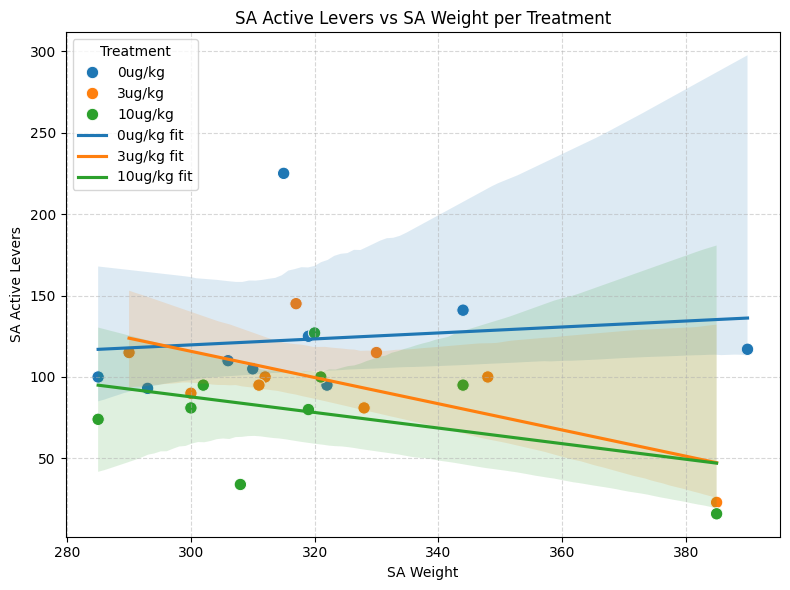

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_weight,
    x="SA Weight",
    y="SA Active levers",
    hue="Treatment_SA",
    s=80
)

# Add regression line per treatment
treatments = df_weight["Treatment_SA"].unique()
colors = sns.color_palette(n_colors=len(treatments))

for i, tr in enumerate(treatments):
    subset = df_weight[df_weight["Treatment_SA"] == tr]
    sns.regplot(
        data=subset,
        x="SA Weight",
        y="SA Active levers",
        scatter=False,
        color=colors[i],
        label=f"{tr} fit"
    )

plt.title("SA Active Levers vs SA Weight per Treatment")
plt.xlabel("SA Weight")
plt.ylabel("SA Active Levers")
plt.legend(title="Treatment")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


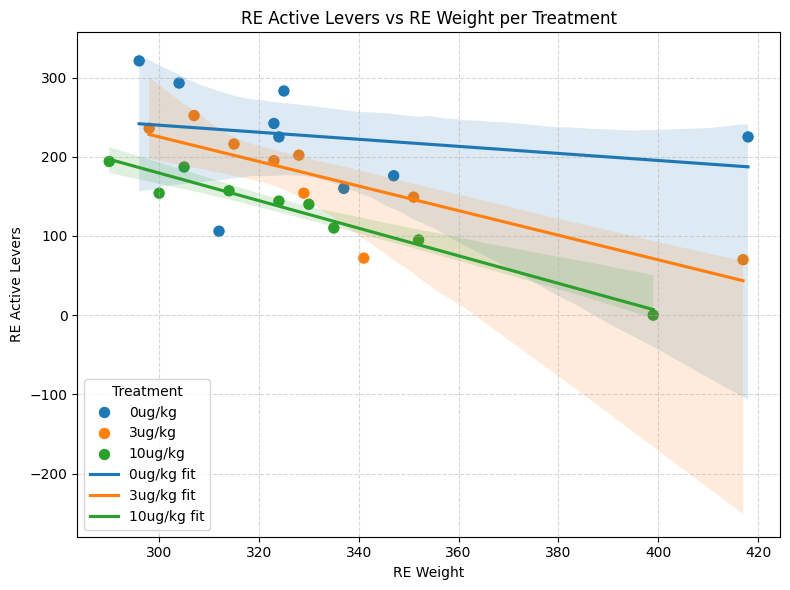

In [45]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_weight,
    x="RE Weight",
    y="RE Active levers",
    hue="Treatment_SA",
    s=80
)

# Add regression line per treatment
for i, tr in enumerate(treatments):
    subset = df_weight[df_weight["Treatment_SA"] == tr]
    sns.regplot(
        data=subset,
        x="RE Weight",
        y="RE Active levers",
        scatter=False,
        color=colors[i],
        label=f"{tr} fit"
    )

plt.title("RE Active Levers vs RE Weight per Treatment")
plt.xlabel("RE Weight")
plt.ylabel("RE Active Levers")
plt.legend(title="Treatment")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
